# **ENSF 444 Final Project**
## Improved Game Recommendation System
### Erin Kim (30211474) and Abia Jahanghir (30208171)

_Summary_

For our final project, we have created a machine learning-based recommendation system that predicts whether a user will like a game using historical user data. We redefined "like" as a combination of review length, hours played, helpful votes, funny votes, and 

#### 1. Import libraries

In [99]:
# Import necessary libraries for data handling, preprocessing, modeling, and evaluation

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### 2. Load dataset

In [43]:
# Load the dataset (the CSV file is  included in the zip file with this file)

# low_memory=False to ensure consistent data type inference across columns
# Prevents issues with mixed datatypes in numerical features such as playtime and engagement metrics
df = pd.read_csv("steam_game_reviews.csv", low_memory=False)

# Display basic structure of dataset
print(df.shape)
print(df.columns)
df.head()

(992153, 8)
Index(['review', 'hours_played', 'helpful', 'funny', 'recommendation', 'date',
       'game_name', 'username'],
      dtype='object')


,review,hours_played,helpful,funny,recommendation,date,game_name,username
0,The game itself is also super fun. The PvP and...,39.9,"1,152",13,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Sentinowl\n224 products in account
1,Never cared much about Warhammer until this ga...,91.5,712,116,Recommended,13 September,"Warhammer 40,000: Space Marine 2",userpig\n248 products in account
2,A salute to all the fallen battle brothers who...,43.3,492,33,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Imparat0r\n112 products in account
3,this game feels like it was made in the mid 20...,16.8,661,15,Recommended,14 September,"Warhammer 40,000: Space Marine 2",Fattest_falcon
4,Reminds me of something I've lost. A genuine g...,24.0,557,4,Recommended,12 September,"Warhammer 40,000: Space Marine 2",Jek\n410 products in account


The dataset is loaded from a CSV file ("steam_game_reviews.csv") containing Steam game reviews and user interaction data. The parameter `low_memory=False` is used to ensure consistent data type inference across columns, which is important for large datasets with mixed data types. Initial inspection of the dataset (shape, columns, and sample rows) is performed to understand its structure and prepare for preprocessing.

####  3. Data cleaning and preprocessing

In [45]:
# Remove duplicate rows to avoid redundant data
df = df.drop_duplicates()

# Fill missing review text with empty strings (required for TF-IDF)
df["review"] = df["review"].fillna("")

# Clean and standardize recommendation column
df["recommendation"] = df["recommendation"].astype(str).str.strip()

# Keep only valid recommendation values
df = df[df["recommendation"].isin(["Recommended", "Not Recommended"])]

# Convert recommendation to binary target:
# Recommended -> 1 (liked)
# Not Recommended -> 0 (not liked)
df["liked"] = df["recommendation"].map({
    "Recommended": 1,
    "Not Recommended": 0
})

# Convert numeric columns from string to numeric values
for col in ["hours_played", "helpful", "funny"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
# Numerical features, such as hours played, were converted to numeric format 
# to  handle invalid or inconsistent entries. Any other missing values were
# imputed using the median.

# Fill missing numeric values
df["hours_played"] = df["hours_played"].fillna(df["hours_played"].median())
df["helpful"] = df["helpful"].fillna(0)
df["funny"] = df["funny"].fillna(0)

# Remove extreme outliers in playtime (not necessary  but improves model performance)
df = df[df["hours_played"] < 1000]

# Apply log transformation to normalize skewed playtime values
df["hours_played"] = np.log1p(df["hours_played"])

# Create additional feature: length of review text
df["review_length"] = df["review"].str.len()

# Check final dataset
print(df[["hours_played", "helpful", "funny", "review_length", "liked"]].describe())
print(df["liked"].value_counts())

        hours_played        helpful          funny  review_length  \
count  992152.000000  992152.000000  992152.000000  992152.000000   
mean        3.917261      15.658372       5.060804     386.709627   
std         1.448680      63.708783      35.437444     810.620102   
min         0.000000       0.000000       0.000000       0.000000   
25%         2.990720       1.000000       0.000000      39.000000   
50%         3.945458       2.000000       0.000000     108.000000   
75%         4.921440       5.000000       0.000000     358.000000   
max         6.908655     999.000000     999.000000    8573.000000   

               liked  
count  992152.000000  
mean        0.812155  
std         0.390589  
min         0.000000  
25%         1.000000  
50%         1.000000  
75%         1.000000  
max         1.000000  
liked
1    805781
0    186371
Name: count, dtype: int64


In this step, the dataset was cleaned and transformed to ensure consistency and suitability for machine learning. Duplicate entries were removed, missing values were handled, and categorical variables were standardized. The recommendation column was converted into a binary target variable representing whether a user liked a game.

Numerical features such as hours played, helpful votes, and funny votes were converted to numeric format and cleaned. A log transformation was applied to hours played to reduce skewness and improve model performance. A new feature, review length, was also created to capture the amount of user engagement in each review.

After preprocessing, the dataset contained 992,152 entries. The data showed a noticeable class imbalance, with approximately 81% of reviews labeled as "liked" and 19% as "not liked." This imbalance is important when evaluating model performance, as metrics such as precision, recall, and F1-score become more informative than accuracy alone.

Additionally, the numerical features showed high variability, particularly in helpful and funny votes, indicating the presence of outliers. These preprocessing steps ensure that the dataset is clean, consistent, and appropriate for training machine learning models.

#### 4. Reduce dataset size (for performance)

In [53]:
# Sampling the dataset to reduce computation time (TF-IDF can be slow on large data)
df_sample = df.sample(n=20000, random_state=42)

Due to the large size of the dataset, a subset of the data is sampled to reduce computational cost and improve training efficiency. This is particularly important when using text-based features such as TF-IDF, which can be computationally expensive. The sample size is chosen to balance performance and efficiency while maintaining representative data distribution.

####  5. Feature Selection

In [55]:
# Define input features (X) and target variable (y)

X = df_sample[["review", "hours_played", "helpful", "funny", "review_length"]]
y = df_sample["liked"]

The input features (X) and target variable (y) are defined in this step. The selected features include both textual data (user reviews) and numerical features such as hours played, helpful votes, and review length. This combination allows the model to capture both user sentiment and behavioral patterns. The target variable represents whether a user recommends a game, forming a binary classification problem.

#### 6. Train test split

In [57]:
# Split data into training and testing sets (80/20 split)
# Stratify ensures class distribution remains consistent

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (16000, 5)
Testing shape: (4000, 5)


The dataset is split into training and testing sets using an 80/20 ratio. Stratified sampling is used to preserve the class distribution of the target variable in both sets. This ensures that the model is evaluated fairly and that performance metrics are reliable. The training set is used to train the models, while the test set is used to evaluate their generalization performance.

#### 7.  Preprocessing pipelines

In [59]:
# TEXT PREPROCESSING:
# Convert review text into numerical vectors using TF-IDF

text_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
    ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
    ("tfidf", TfidfVectorizer(max_features=1000, stop_words="english"))
])

# NUMERICAL PREPROCESSING:
# Handle missing values and scale features

numeric_features = ["hours_played", "helpful", "funny", "review_length"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combine text and numerical preprocessing into one pipeline

preprocessor = ColumnTransformer([
    ("text", text_transformer, ["review"]),
    ("num", numeric_transformer, numeric_features)
])

Preprocessing pipelines are created to transform both text and numerical features. Text data is converted into numerical representations using TF-IDF vectorization, which captures the importance of words in reviews. Numerical features are scaled using standardization to ensure consistent feature magnitudes. These transformations are combined using a ColumnTransformer, allowing both types of features to be processed simultaneously within a unified pipeline.

#### 8. Model definitions

In [61]:
# Logistic Regression (Linear model)
logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Random Forest (Non-linear model)
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

# K-Nearest Neighbours (Non-linear model)
knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

Three machine learning models are selected for comparison: Logistic Regression, Random Forest, and K-Nearest Neighbours. Logistic Regression serves as a baseline linear model, while Random Forest and KNN are non-linear models capable of capturing more complex relationships. This selection satisfies the requirement of comparing multiple models, including at least two non-linear approaches.

#### 9. Moddel evalutation function

In [63]:
# Function to train and evaluate models using multiple metrics

def evaluate(name, model):
    # Train model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Print evaluation metrics
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

A reusable evaluation function is defined to train each model and compute performance metrics. The models are evaluated using accuracy, precision, recall, and F1-score, which provide a comprehensive assessment of classification performance. This approach ensures consistent evaluation across all models and simplifies comparison.

#### 10. Run models

In [65]:
# Evaluate all three models

evaluate("Logistic Regression", logreg)
evaluate("Random Forest", rf)
evaluate("KNN", knn)


Logistic Regression
Accuracy: 0.83625
Precision: 0.9481865284974094
Recall: 0.8446153846153847
F1-score: 0.8934092758340114

Random Forest
Accuracy: 0.87625
Precision: 0.8802097709080873
Recall: 0.9812307692307692
F1-score: 0.9279790484504583

KNN
Accuracy: 0.82725
Precision: 0.8455306508236565
Recall: 0.9633846153846154
F1-score: 0.9006184380842802


#### Recorded Scores: 
__Logistic Regression__
Accuracy: 0.83625
Precision: 0.9481865284974094
Recall: 0.8446153846153847
F1-score: 0.8934092758340114

__Random Forest__
Accuracy: 0.87625
Precision: 0.8802097709080873
Recall: 0.9812307692307692
F1-score: 0.9279790484504583

__KNN__
Accuracy: 0.82725
Precision: 0.8455306508236565
Recall: 0.9633846153846154
F1-score: 0.9006184380842802

All three models were trained and evaluated using accuracy, precision, recall, and F1-score. The results demonstrate clear differences in model performance.

Logistic Regression achieved strong precision (0.948), indicating that when it predicts a game is liked, it is usually correct. However, its recall (0.845) is lower, meaning it misses some positive cases.

Random Forest achieved the best overall performance, with the highest accuracy (0.876) and F1-score (0.928). It also achieved extremely high recall (0.981), meaning it correctly identifies most liked games. This indicates that Random Forest is the most effective model for this classification task.

K-Nearest Neighbours achieved high recall (0.963), but lower precision (0.846) and accuracy (0.827), suggesting that it tends to over-predict the positive class.

Overall, Random Forest provides the best balance between precision and recall, making it the strongest model for predicting user preferences in this dataset.

#### 11. Confusion matrix of the best model

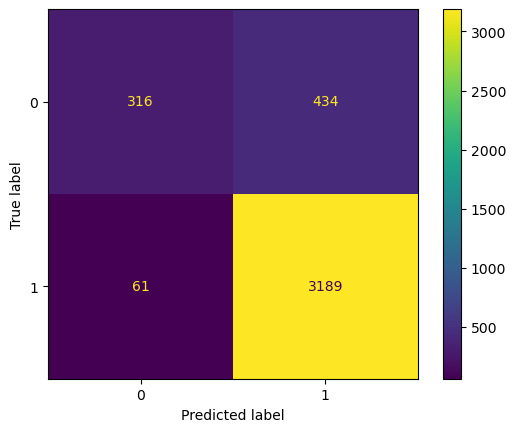

In [67]:
# Visualize performance of the best model (Random Forest)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

The confusion matrix provides a detailed breakdown of the model’s predictions. The model correctly identified 3189 true positives (liked games) and 316 true negatives (not liked games). There were 434 false positives, where the model predicted a game would be liked when it was not, and only 61 false negatives.

These results indicate that the model is highly effective at identifying positive cases, which aligns with the high recall observed earlier. The relatively low number of false negatives shows that the model rarely misses games that users would have liked.

Although the number of false positives is higher, this trade-off is acceptable in the context of a recommendation system. A false positive corresponds to recommending a game that the user may not enjoy, which has a relatively low cost since users can simply ignore it. In contrast, a false negative represents a missed opportunity to recommend a game the user would have enjoyed.

Therefore, the model prioritizes recall over precision, ensuring that most relevant games are recommended even at the cost of additional false positives. This trade-off aligns with the goal of maximizing user engagement and improving the overall recommendation experience.

#### 12. Cross validation

In [69]:
# Perform cross-validation to assess model generalization

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring="f1")
print("Cross-validation F1 scores:", scores)
print("Mean F1 score:", scores.mean())

Cross-validation F1 scores: [0.92973761 0.93066706 0.93158279 0.92585054 0.92878986]
Mean F1 score: 0.9293255708075667


#### Recorded Scores: 
__Cross-validation F1 scores__: [0.92973761 0.93066706 0.93158279 0.92585054 0.92878986]
__Mean F1 score__ : 0.9293255708075667

Cross-validation was performed to evaluate the stability and generalization of the Random Forest model. The F1-scores across the five folds were [0.9297, 0.9307, 0.9316, 0.9259, 0.9288], with an average F1-score of approximately 0.9293.

These results are highly consistent, indicating that the model performs reliably across different subsets of the data and is not overfitting. This further supports the selection of Random Forest as the final model.

# __Notes for later__
1. Try to combine different datasets
2. justify why KNN is used even in a large scale

#### Notes from proposal feedback
1. Dataset integration is unclear (important)
You listed multiple datasets, but:
How will they be merged?
What is the common key (user_id, game_id)?

2. Model choices could be stronger
KNN is not scalable for large datasets like Steam
No advanced model for text (e.g., TF-IDF + linear model is fine, but explain)